# Statistics for Machine Learning — Notebook 4  
# Sampling, Confidence Intervals, and Hypothesis Testing

## Why this notebook matters

In Machine Learning and Data Science, we often work with samples.

We train a model on sample data.  
We test it on sample data.  
We compare two models using sample results.  
We run A/B tests on sample users.  
We estimate business metrics using sample behavior.

But the real question is:

> Can we trust the result?

Example:

Model A accuracy = 84%  
Model B accuracy = 85%

Is Model B truly better?  
Or is this difference just random chance?

That is why we need:

- sampling
- sampling distributions
- standard error
- confidence intervals
- hypothesis testing
- p-values
- statistical significance
- A/B testing

---

## What you will learn

1. Population vs sample revisited  
2. Sampling variation  
3. Sampling distribution  
4. Standard error  
5. Central Limit Theorem  
6. Confidence interval for mean  
7. Confidence interval for proportion  
8. Bootstrap confidence intervals  
9. Hypothesis testing intuition  
10. p-values  
11. Type I and Type II errors  
12. One-sample t-test  
13. Two-sample t-test  
14. Paired t-test  
15. Chi-square test  
16. A/B testing  
17. Multiple testing warning  
18. ML experiment interpretation  
19. Mini project: A/B test and model comparison report

# 1. Big idea: sample results are uncertain

Suppose a website has 1,000,000 users.

We cannot always study every user.

So we take a sample:

```text
sample = 1,000 users
```

If the sample conversion rate is 6%, is the real conversion rate exactly 6%?

No.

The sample estimate has uncertainty.

Statistics helps us measure that uncertainty.

---

## In ML

When we evaluate a model on a test set, the metric is also a sample estimate.

Example:

```text
test accuracy = 0.84
```

This does not mean the true future accuracy is exactly 0.84.

It means:

> Based on this test sample, we estimate model accuracy around 0.84.

# 2. Setup

Run this cell first.

If something is missing:

```python
!pip install numpy pandas matplotlib seaborn scipy scikit-learn ipywidgets
```

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, t, ttest_1samp, ttest_ind, ttest_rel, chi2_contingency

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not available. Install it using: pip install ipywidgets")

np.random.seed(42)

%matplotlib inline
sns.set_theme(style="whitegrid")

print("Setup complete.")

Setup complete.


# 3. Population vs sample

## Population

The full group we care about.

Examples:

- all customers
- all users
- all future transactions
- all possible images
- all future model predictions

## Sample

A smaller group selected from the population.

In machine learning, the dataset is usually a sample of the real world.

The model should generalize from sample to population.

Population mean: 51.69
Sample mean: 52.36
Population median: 40.5
Sample median: 40.45


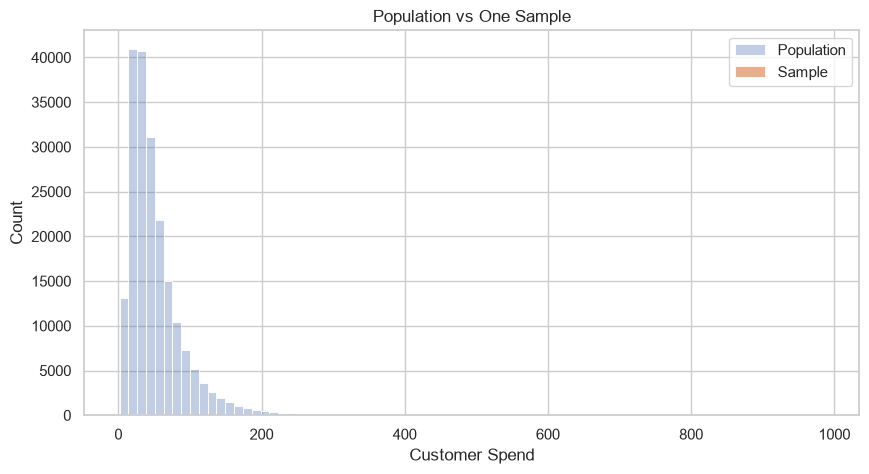

In [2]:
# Create a fake population of customer spending values
population_size = 200000

population_spend = np.random.lognormal(mean=3.7, sigma=0.7, size=population_size)

population_mean = population_spend.mean()
population_median = np.median(population_spend)

sample = np.random.choice(population_spend, size=500, replace=False)

sample_mean = sample.mean()
sample_median = np.median(sample)

print("Population mean:", round(population_mean, 2))
print("Sample mean:", round(sample_mean, 2))
print("Population median:", round(population_median, 2))
print("Sample median:", round(sample_median, 2))

plt.figure(figsize=(10, 5))
sns.histplot(population_spend, bins=80, label="Population", alpha=0.35)
sns.histplot(sample, bins=40, label="Sample", alpha=0.65)
plt.title("Population vs One Sample")
plt.xlabel("Customer Spend")
plt.ylabel("Count")
plt.legend()
plt.show()

# 4. Sampling variation

If we take many samples from the same population, each sample mean will be slightly different.

This is called sampling variation.

It happens because every sample contains different observations.

Population mean: 51.69
Average of sample means: 51.79
Standard deviation of sample means: 1.91


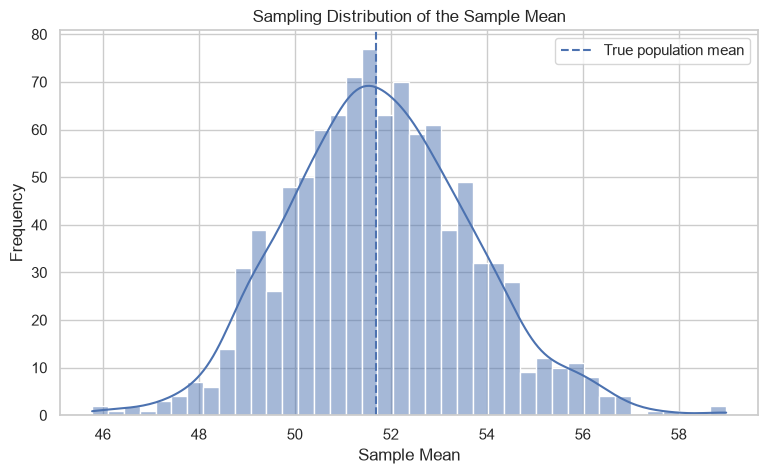

In [3]:
sample_means = []

for i in range(1000):
    sample_i = np.random.choice(population_spend, size=500, replace=False)
    sample_means.append(sample_i.mean())

sample_means = np.array(sample_means)

print("Population mean:", round(population_mean, 2))
print("Average of sample means:", round(sample_means.mean(), 2))
print("Standard deviation of sample means:", round(sample_means.std(), 2))

plt.figure(figsize=(9, 5))
sns.histplot(sample_means, bins=40, kde=True)
plt.axvline(population_mean, linestyle="--", label="True population mean")
plt.title("Sampling Distribution of the Sample Mean")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 5. Sampling distribution

A sampling distribution is the distribution of a statistic over many samples.

Example statistic:

```text
sample mean
```

If we take many samples and calculate the mean of each sample, those means form a sampling distribution.

This is central to confidence intervals and hypothesis testing.

# 6. Standard error

Standard error measures how much a sample statistic varies from sample to sample.

For the sample mean:

```text
standard error = sample standard deviation / sqrt(sample size)
```

Important:

- standard deviation measures spread of individual values
- standard error measures uncertainty of sample mean

Larger sample size means smaller standard error.

In [4]:
sample_size = 500

sample_std = sample.std(ddof=1)
standard_error_formula = sample_std / np.sqrt(sample_size)

estimated_standard_error_from_simulation = sample_means.std(ddof=1)

print("Standard error using formula:", round(standard_error_formula, 3))
print("Standard error from simulation:", round(estimated_standard_error_from_simulation, 3))

Standard error using formula: 2.07
Standard error from simulation: 1.916


# 7. Effect of sample size on standard error

As sample size increases, the standard error decreases.

This means larger samples give more stable estimates.

,sample_size,mean_of_sample_means,standard_error_simulated,standard_error_formula
0,20,51.458,9.194,9.141
1,50,51.615,5.994,5.781
2,100,52.058,4.184,4.088
3,250,51.661,2.618,2.585
4,500,51.584,1.858,1.828
5,1000,51.664,1.330,1.293
6,3000,51.724,0.753,0.746


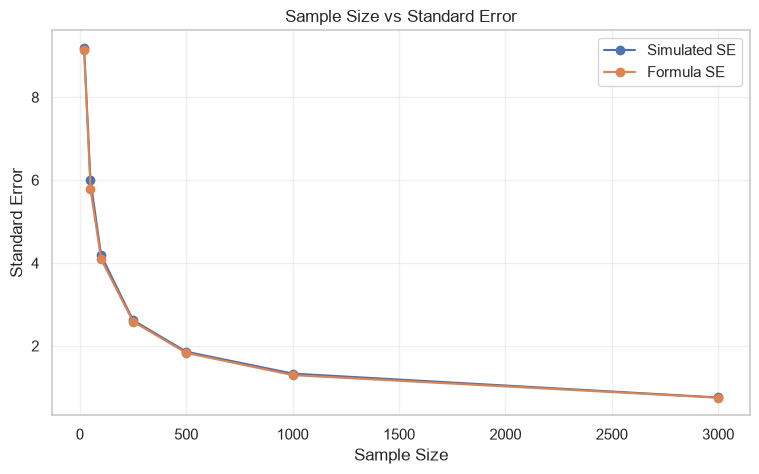

In [5]:
sample_sizes = [20, 50, 100, 250, 500, 1000, 3000]
rows = []

for size in sample_sizes:
    means = []
    for i in range(500):
        s = np.random.choice(population_spend, size=size, replace=False)
        means.append(s.mean())

    rows.append({
        "sample_size": size,
        "mean_of_sample_means": np.mean(means),
        "standard_error_simulated": np.std(means, ddof=1),
        "standard_error_formula": np.std(population_spend, ddof=1) / np.sqrt(size)
    })

se_df = pd.DataFrame(rows)
display(se_df.round(3))

plt.figure(figsize=(9, 5))
plt.plot(se_df["sample_size"], se_df["standard_error_simulated"], marker="o", label="Simulated SE")
plt.plot(se_df["sample_size"], se_df["standard_error_formula"], marker="o", label="Formula SE")
plt.title("Sample Size vs Standard Error")
plt.xlabel("Sample Size")
plt.ylabel("Standard Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Central Limit Theorem

Central Limit Theorem is one of the most important ideas in statistics.

It says:

> If sample size is large enough, the sampling distribution of the sample mean becomes approximately normal, even if the original population is not normal.

This is powerful because many real datasets are skewed, but sample means can still behave normally.

This is why confidence intervals and hypothesis tests often work.

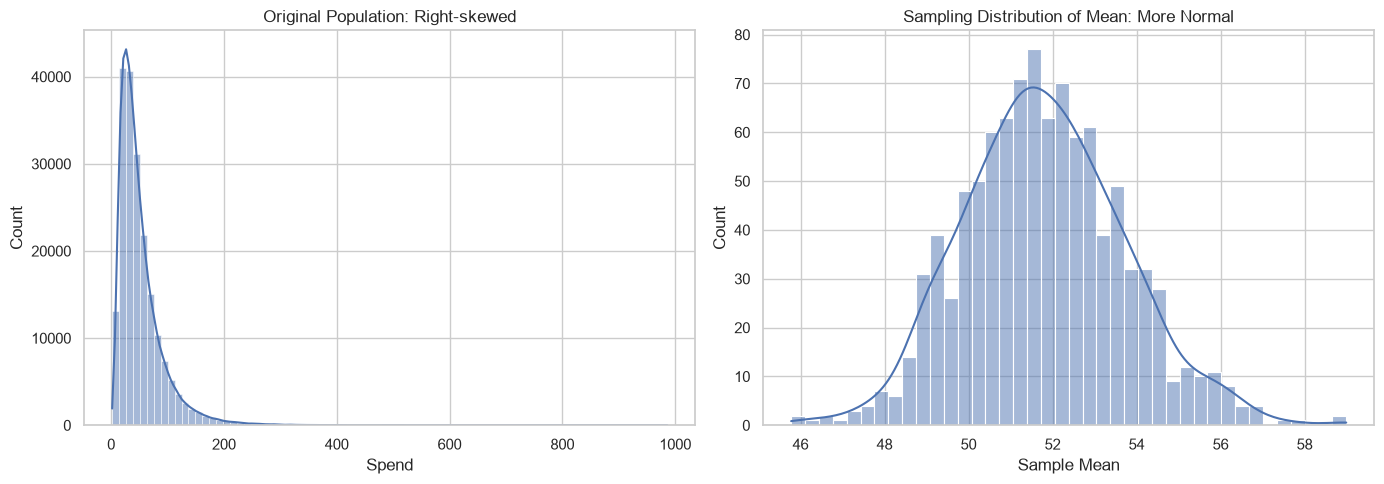

In [6]:
# The population is strongly right-skewed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(population_spend, bins=80, kde=True, ax=axes[0])
axes[0].set_title("Original Population: Right-skewed")
axes[0].set_xlabel("Spend")

sns.histplot(sample_means, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Sampling Distribution of Mean: More Normal")
axes[1].set_xlabel("Sample Mean")

plt.tight_layout()
plt.show()

# 9. Interactive Central Limit Theorem demo

Change sample size.

Notice:

- small samples produce wider, less stable sample means
- larger samples produce narrower, more normal sampling distribution

In [7]:
def clt_demo(sample_size=30):
    means = []

    for i in range(1000):
        s = np.random.choice(population_spend, size=sample_size, replace=False)
        means.append(s.mean())

    means = np.array(means)

    plt.figure(figsize=(9, 5))
    sns.histplot(means, bins=40, kde=True)
    plt.axvline(population_mean, linestyle="--", label="True population mean")
    plt.title(f"Sampling Distribution of Mean | sample size = {sample_size}")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    print("Mean of sample means:", round(means.mean(), 2))
    print("Standard error:", round(means.std(ddof=1), 2))

if WIDGETS_AVAILABLE:
    interact(
        clt_demo,
        sample_size=widgets.IntSlider(value=30, min=5, max=1000, step=5)
    )
else:
    clt_demo(30)

interactive(children=(IntSlider(value=30, description='sample_size', max=1000, min=5, step=5), Output()), _dom…

# 10. Confidence interval intuition

A confidence interval gives a range of plausible values for a population parameter.

Example:

```text
Sample mean spend = 42.50
95% confidence interval = [40.80, 44.20]
```

Meaning:

> Based on this sample, the true population mean is plausibly between 40.80 and 44.20.

Important:

A 95% confidence interval does not mean there is a 95% probability that this specific interval contains the true mean.

The correct frequentist interpretation:

> If we repeated the sampling process many times, about 95% of such intervals would contain the true population mean.

# 11. Confidence interval for a mean

Formula idea:

```text
sample mean ± critical value × standard error
```

When population standard deviation is unknown, we usually use the t-distribution.

For 95% confidence:

```python
stats.t.interval(...)
```

In [8]:
sample_size = 500
sample = np.random.choice(population_spend, size=sample_size, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)
standard_error = sample_std / np.sqrt(sample_size)

confidence_level = 0.95
degrees_freedom = sample_size - 1

critical_value = t.ppf((1 + confidence_level) / 2, df=degrees_freedom)

margin_of_error = critical_value * standard_error

ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print("Sample mean:", round(sample_mean, 2))
print("Standard error:", round(standard_error, 3))
print("Critical value:", round(critical_value, 3))
print("Margin of error:", round(margin_of_error, 2))
print("95% CI:", (round(ci_lower, 2), round(ci_upper, 2)))
print("True population mean:", round(population_mean, 2))

Sample mean: 52.33
Standard error: 1.894
Critical value: 1.965
Margin of error: 3.72
95% CI: (np.float64(48.61), np.float64(56.05))
True population mean: 51.69


# 12. Visualize confidence interval

The dot is the sample mean.  
The line is the confidence interval.

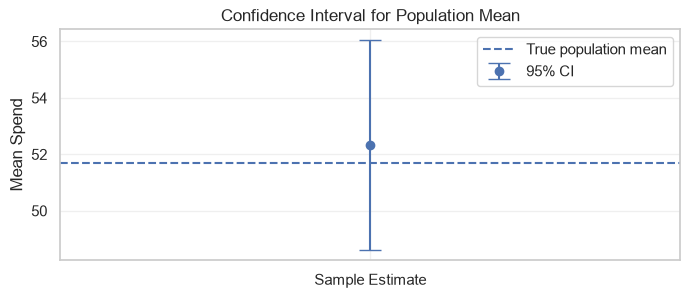

In [9]:
plt.figure(figsize=(8, 3))

plt.errorbar(
    x=[0],
    y=[sample_mean],
    yerr=[[sample_mean - ci_lower], [ci_upper - sample_mean]],
    fmt="o",
    capsize=8,
    label="95% CI"
)

plt.axhline(population_mean, linestyle="--", label="True population mean")
plt.xticks([0], ["Sample Estimate"])
plt.ylabel("Mean Spend")
plt.title("Confidence Interval for Population Mean")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 13. Confidence interval coverage simulation

If we create many 95% confidence intervals, around 95% should contain the true population mean.

Coverage: 0.955


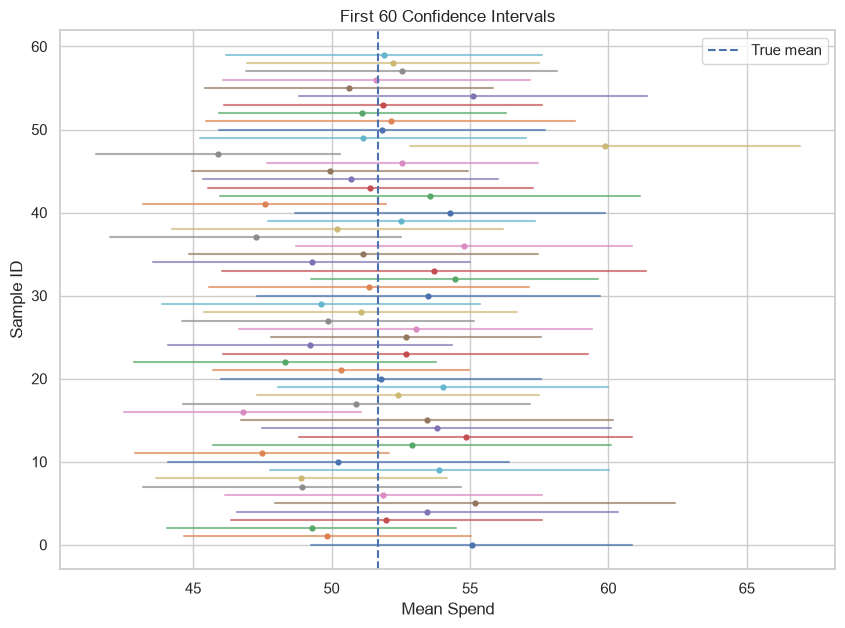

In [10]:
n_intervals = 200
sample_size = 200

interval_rows = []

for i in range(n_intervals):
    s = np.random.choice(population_spend, size=sample_size, replace=False)
    mean_i = s.mean()
    std_i = s.std(ddof=1)
    se_i = std_i / np.sqrt(sample_size)
    crit_i = t.ppf(0.975, df=sample_size - 1)

    lower_i = mean_i - crit_i * se_i
    upper_i = mean_i + crit_i * se_i
    contains = lower_i <= population_mean <= upper_i

    interval_rows.append({
        "sample_id": i,
        "mean": mean_i,
        "lower": lower_i,
        "upper": upper_i,
        "contains_true_mean": contains
    })

interval_df = pd.DataFrame(interval_rows)

coverage = interval_df["contains_true_mean"].mean()

print("Coverage:", round(coverage, 3))

plt.figure(figsize=(10, 7))

for i, row in interval_df.head(60).iterrows():
    plt.plot([row["lower"], row["upper"]], [i, i], alpha=0.7)
    plt.scatter(row["mean"], i, s=12)

plt.axvline(population_mean, linestyle="--", label="True mean")
plt.title("First 60 Confidence Intervals")
plt.xlabel("Mean Spend")
plt.ylabel("Sample ID")
plt.legend()
plt.show()

# 14. Confidence interval for a proportion

A proportion is a percentage-like value.

Examples:

- churn rate
- conversion rate
- fraud rate
- model accuracy
- click-through rate

Approximate confidence interval for a proportion:

```text
p_hat ± z × sqrt(p_hat(1-p_hat)/n)
```

Where:

- p_hat = sample proportion
- n = sample size
- z = critical value

In [11]:
# Example: conversion rate
n_users = 2000
conversions = 126

p_hat = conversions / n_users

z_critical = norm.ppf(0.975)
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_users)

ci_lower = p_hat - z_critical * se_prop
ci_upper = p_hat + z_critical * se_prop

print("Sample conversion rate:", round(p_hat, 4))
print("Standard error:", round(se_prop, 4))
print("95% CI:", (round(ci_lower, 4), round(ci_upper, 4)))
print("95% CI percentage:", (round(ci_lower * 100, 2), round(ci_upper * 100, 2)))

Sample conversion rate: 0.063
Standard error: 0.0054
95% CI: (np.float64(0.0524), np.float64(0.0736))
95% CI percentage: (np.float64(5.24), np.float64(7.36))


# 15. Confidence interval for model accuracy

Accuracy is a proportion:

```text
number of correct predictions / total predictions
```

So we can build a confidence interval for accuracy.

This helps answer:

> How uncertain is this test accuracy?

In [12]:
n_test = 1000
correct_predictions = 850

accuracy = correct_predictions / n_test

se_acc = np.sqrt(accuracy * (1 - accuracy) / n_test)
ci_lower = accuracy - z_critical * se_acc
ci_upper = accuracy + z_critical * se_acc

print("Test accuracy:", round(accuracy, 3))
print("95% CI for accuracy:", (round(ci_lower, 3), round(ci_upper, 3)))

Test accuracy: 0.85
95% CI for accuracy: (np.float64(0.828), np.float64(0.872))


# 16. Bootstrap confidence interval

Bootstrap is a simulation method.

Steps:

1. Take your sample
2. Resample from it with replacement
3. Calculate statistic
4. Repeat many times
5. Use percentiles of bootstrap statistics as confidence interval

Bootstrap is useful when formulas are difficult.

Sample mean: 54.46
Bootstrap 95% CI: (np.float64(50.43), np.float64(58.54))
True population mean: 51.69


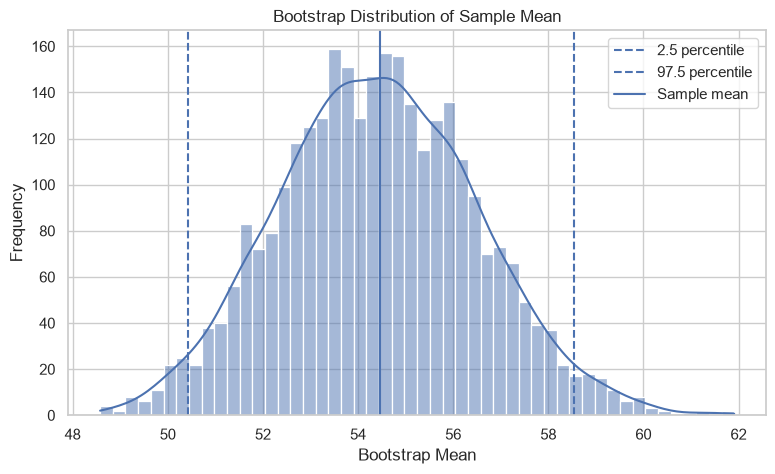

In [13]:
sample = np.random.choice(population_spend, size=500, replace=False)

bootstrap_means = []

for i in range(3000):
    boot_sample = np.random.choice(sample, size=len(sample), replace=True)
    bootstrap_means.append(boot_sample.mean())

bootstrap_means = np.array(bootstrap_means)

boot_lower = np.percentile(bootstrap_means, 2.5)
boot_upper = np.percentile(bootstrap_means, 97.5)

print("Sample mean:", round(sample.mean(), 2))
print("Bootstrap 95% CI:", (round(boot_lower, 2), round(boot_upper, 2)))
print("True population mean:", round(population_mean, 2))

plt.figure(figsize=(9, 5))
sns.histplot(bootstrap_means, bins=50, kde=True)
plt.axvline(boot_lower, linestyle="--", label="2.5 percentile")
plt.axvline(boot_upper, linestyle="--", label="97.5 percentile")
plt.axvline(sample.mean(), linestyle="-", label="Sample mean")
plt.title("Bootstrap Distribution of Sample Mean")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 17. Hypothesis testing intuition

Hypothesis testing helps us decide whether an observed result is surprising under a null assumption.

Example:

A company says average customer spend is $45.

We collect a sample and find average spend is $49.

Question:

> Is this difference real or just random sample noise?

We define:

## Null hypothesis H0

No effect / no difference / default assumption.

```text
H0: population mean = 45
```

## Alternative hypothesis H1

There is an effect / difference.

```text
H1: population mean != 45
```

# 18. p-value intuition

A p-value answers:

> If the null hypothesis were true, how likely would we be to see a result this extreme or more extreme?

Small p-value means:

> The observed result would be unusual if H0 were true.

Common threshold:

```text
alpha = 0.05
```

If:

```text
p-value < 0.05
```

We reject the null hypothesis.

Important:

A p-value is not the probability that H0 is true.

# 19. One-sample t-test

Used when comparing sample mean to a known or claimed value.

Example:

```text
H0: average spend = 45
H1: average spend != 45
```

In [14]:
claimed_mean = 45

sample = np.random.choice(population_spend, size=400, replace=False)

t_stat, p_value = ttest_1samp(sample, popmean=claimed_mean)

print("Sample mean:", round(sample.mean(), 2))
print("Claimed mean:", claimed_mean)
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 5))

alpha = 0.05

if p_value < alpha:
    print("Reject H0: sample provides evidence that mean differs from claimed mean.")
else:
    print("Fail to reject H0: not enough evidence that mean differs.")

Sample mean: 49.88
Claimed mean: 45
t-statistic: 2.528
p-value: 0.01184
Reject H0: sample provides evidence that mean differs from claimed mean.


# 20. Two-sample t-test

Used to compare means of two independent groups.

Example:

```text
Group A = old website
Group B = new website
```

Question:

> Is average order value different between A and B?

Hypotheses:

```text
H0: mean_A = mean_B
H1: mean_A != mean_B
```

Group A mean: 49.82
Group B mean: 53.55
Difference: 3.73
t-statistic: -5.053
p-value: 0.0


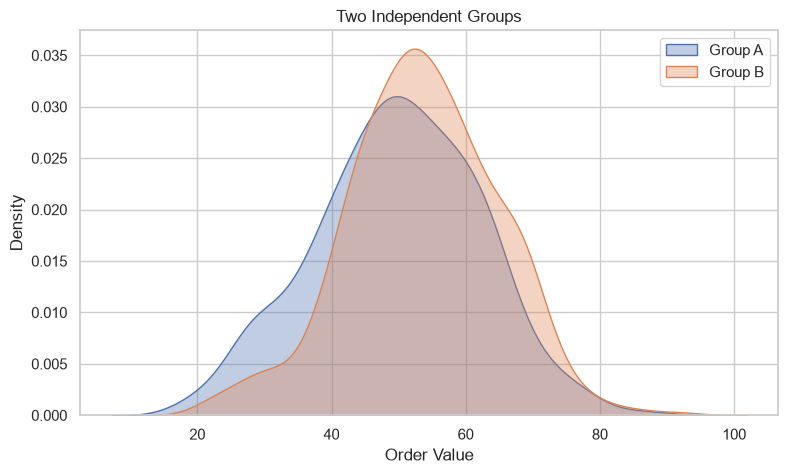

Reject H0: groups have statistically different means.


In [15]:
# Simulate two independent groups

group_A = np.random.normal(loc=50, scale=12, size=500)
group_B = np.random.normal(loc=53, scale=12, size=520)

t_stat, p_value = ttest_ind(group_A, group_B, equal_var=False)

print("Group A mean:", round(group_A.mean(), 2))
print("Group B mean:", round(group_B.mean(), 2))
print("Difference:", round(group_B.mean() - group_A.mean(), 2))
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 5))

plt.figure(figsize=(9, 5))
sns.kdeplot(group_A, fill=True, label="Group A", alpha=0.35)
sns.kdeplot(group_B, fill=True, label="Group B", alpha=0.35)
plt.title("Two Independent Groups")
plt.xlabel("Order Value")
plt.legend()
plt.show()

if p_value < 0.05:
    print("Reject H0: groups have statistically different means.")
else:
    print("Fail to reject H0: difference may be random noise.")

# 21. Paired t-test

Used when the same subjects are measured twice.

Examples:

- same customers before and after offer
- same model evaluated before and after calibration on same folds
- same students before and after training

Hypotheses:

```text
H0: mean difference = 0
H1: mean difference != 0
```

Before mean: 69.46
After mean: 72.59
Mean difference: 3.14
t-statistic: -9.774
p-value: 0.0


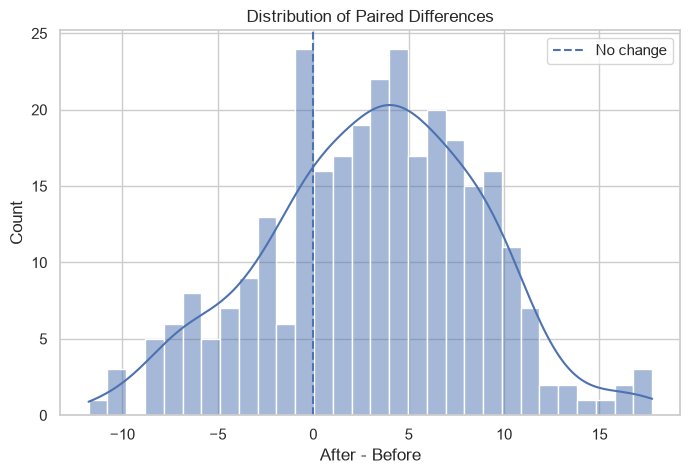

Reject H0: statistically significant paired difference.


In [16]:
# Same customers before and after improvement

before = np.random.normal(loc=70, scale=10, size=300)
after = before + np.random.normal(loc=3, scale=6, size=300)

t_stat, p_value = ttest_rel(before, after)

print("Before mean:", round(before.mean(), 2))
print("After mean:", round(after.mean(), 2))
print("Mean difference:", round((after - before).mean(), 2))
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 5))

plt.figure(figsize=(8, 5))
sns.histplot(after - before, bins=30, kde=True)
plt.axvline(0, linestyle="--", label="No change")
plt.title("Distribution of Paired Differences")
plt.xlabel("After - Before")
plt.legend()
plt.show()

if p_value < 0.05:
    print("Reject H0: statistically significant paired difference.")
else:
    print("Fail to reject H0: not enough evidence of difference.")

# 22. Chi-square test of independence

Used for categorical variables.

Example:

```text
Is churn independent of customer segment?
```

Hypotheses:

```text
H0: churn and segment are independent
H1: churn and segment are associated
```

churn,0,1
segment,,
Budget,571,228
Premium,304,24
Regular,714,159


Chi-square statistic: 69.307
p-value: 0.0
Degrees of freedom: 2


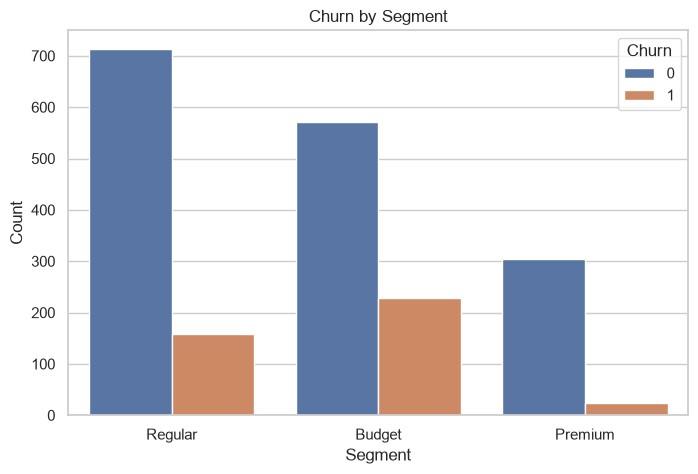

Reject H0: churn and segment are associated.


In [17]:
# Create categorical customer dataset

n = 2000

segments = np.random.choice(["Budget", "Regular", "Premium"], size=n, p=[0.4, 0.45, 0.15])

churn_probs = np.where(
    segments == "Budget",
    0.28,
    np.where(segments == "Regular", 0.18, 0.10)
)

churn = np.random.binomial(1, churn_probs)

cat_df = pd.DataFrame({
    "segment": segments,
    "churn": churn
})

contingency_table = pd.crosstab(cat_df["segment"], cat_df["churn"])

display(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2_stat, 3))
print("p-value:", round(p_value, 6))
print("Degrees of freedom:", dof)

plt.figure(figsize=(8, 5))
sns.countplot(data=cat_df, x="segment", hue="churn")
plt.title("Churn by Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

if p_value < 0.05:
    print("Reject H0: churn and segment are associated.")
else:
    print("Fail to reject H0: no strong evidence of association.")

# 23. Type I and Type II errors

Hypothesis testing can make mistakes.

## Type I error

Rejecting H0 when H0 is actually true.

Example:

> We think new model is better, but it is not.

This is controlled by alpha, commonly 0.05.

## Type II error

Failing to reject H0 when H1 is actually true.

Example:

> New model is actually better, but our test fails to detect it.

This is related to statistical power.

In [18]:
error_table = pd.DataFrame({
    "Decision": ["Reject H0", "Fail to reject H0"],
    "H0 True": ["Type I Error", "Correct Decision"],
    "H1 True": ["Correct Decision", "Type II Error"]
})

display(error_table)

,Decision,H0 True,H1 True
0,Reject H0,Type I Error,Correct Decision
1,Fail to reject H0,Correct Decision,Type II Error


# 24. Statistical power intuition

Power is the probability of detecting a real effect.

Power increases when:

- sample size is larger
- effect size is larger
- data noise is smaller
- alpha threshold is larger

In ML experiments, small test sets may fail to detect real improvements.

,effect_size_difference,detection_rate
0,0.0,0.047
1,0.5,0.087
2,1.0,0.184
3,2.0,0.505
4,3.0,0.841
5,5.0,0.999


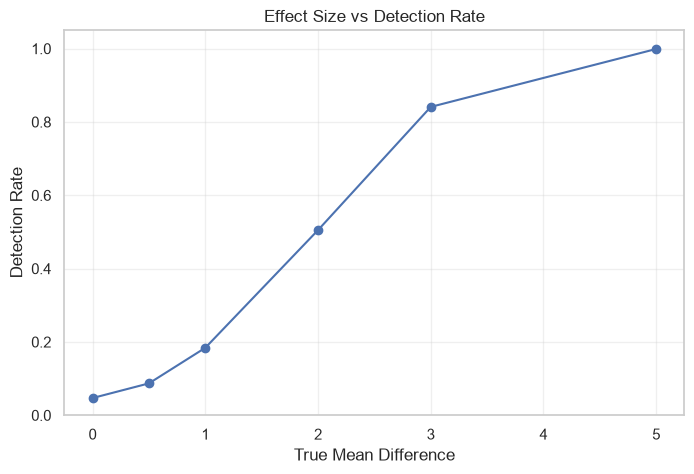

In [19]:
effect_sizes = [0, 0.5, 1, 2, 3, 5]
sample_size = 200
n_simulations = 1000

power_rows = []

for effect in effect_sizes:
    significant_count = 0

    for i in range(n_simulations):
        a = np.random.normal(loc=50, scale=10, size=sample_size)
        b = np.random.normal(loc=50 + effect, scale=10, size=sample_size)

        _, p = ttest_ind(a, b, equal_var=False)

        if p < 0.05:
            significant_count += 1

    power_rows.append({
        "effect_size_difference": effect,
        "detection_rate": significant_count / n_simulations
    })

power_df = pd.DataFrame(power_rows)

display(power_df.round(3))

plt.figure(figsize=(8, 5))
plt.plot(power_df["effect_size_difference"], power_df["detection_rate"], marker="o")
plt.title("Effect Size vs Detection Rate")
plt.xlabel("True Mean Difference")
plt.ylabel("Detection Rate")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

# 25. A/B testing

A/B testing compares two versions.

Example:

- Version A: old website
- Version B: new website

Metric:

- conversion rate
- click rate
- revenue
- retention
- model acceptance rate

Question:

> Is B better than A, or is the difference due to random chance?

In [20]:
# Simulate A/B test conversion data

n_A = 5000
n_B = 5200

true_conversion_A = 0.055
true_conversion_B = 0.064

conversions_A = np.random.binomial(1, true_conversion_A, size=n_A)
conversions_B = np.random.binomial(1, true_conversion_B, size=n_B)

rate_A = conversions_A.mean()
rate_B = conversions_B.mean()

print("A conversion rate:", round(rate_A, 4))
print("B conversion rate:", round(rate_B, 4))
print("Difference:", round(rate_B - rate_A, 4))

A conversion rate: 0.0562
B conversion rate: 0.0631
Difference: 0.0069


# 26. Two-proportion z-test for A/B testing

For conversion rates, we compare two proportions.

Hypotheses:

```text
H0: conversion_A = conversion_B
H1: conversion_A != conversion_B
```

We calculate z-statistic and p-value.

In [21]:
x_A = conversions_A.sum()
x_B = conversions_B.sum()

p_A = x_A / n_A
p_B = x_B / n_B

# pooled proportion under H0
p_pool = (x_A + x_B) / (n_A + n_B)

se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))

z_stat = (p_B - p_A) / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("Conversions A:", x_A, "out of", n_A)
print("Conversions B:", x_B, "out of", n_B)
print("Rate A:", round(p_A, 4))
print("Rate B:", round(p_B, 4))
print("z-statistic:", round(z_stat, 3))
print("p-value:", round(p_value, 5))

if p_value < 0.05:
    print("Reject H0: statistically significant conversion difference.")
else:
    print("Fail to reject H0: not enough evidence of conversion difference.")

Conversions A: 281 out of 5000
Conversions B: 328 out of 5200
Rate A: 0.0562
Rate B: 0.0631
z-statistic: 1.465
p-value: 0.14283
Fail to reject H0: not enough evidence of conversion difference.


# 27. Confidence interval for difference in proportions

A/B testing should not only show p-value.

We should also show effect size and confidence interval.

Here we calculate CI for:

```text
conversion_B - conversion_A
```

In [ ]:
diff = p_B - p_A

se_diff = np.sqrt(
    p_A * (1 - p_A) / n_A
    + p_B * (1 - p_B) / n_B
)

ci_lower = diff - z_critical * se_diff
ci_upper = diff + z_critical * se_diff

print("Difference B - A:", round(diff, 4))
print("95% CI for difference:", (round(ci_lower, 4), round(ci_upper, 4)))
print("Percentage point CI:", (round(ci_lower * 100, 2), round(ci_upper * 100, 2)))

# 28. A/B testing visualization

We visualize conversion rates and confidence intervals.

In [ ]:
ab_summary = pd.DataFrame({
    "group": ["A", "B"],
    "conversion_rate": [p_A, p_B],
    "n": [n_A, n_B]
})

ab_summary["se"] = np.sqrt(ab_summary["conversion_rate"] * (1 - ab_summary["conversion_rate"]) / ab_summary["n"])
ab_summary["lower"] = ab_summary["conversion_rate"] - z_critical * ab_summary["se"]
ab_summary["upper"] = ab_summary["conversion_rate"] + z_critical * ab_summary["se"]

display(ab_summary)

plt.figure(figsize=(7, 5))
plt.bar(ab_summary["group"], ab_summary["conversion_rate"])
plt.errorbar(
    ab_summary["group"],
    ab_summary["conversion_rate"],
    yerr=[
        ab_summary["conversion_rate"] - ab_summary["lower"],
        ab_summary["upper"] - ab_summary["conversion_rate"]
    ],
    fmt="none",
    capsize=8
)
plt.title("A/B Test Conversion Rates with 95% CI")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

# 29. Interactive A/B test simulator

Change sample size and true conversion rates.

Notice:

- larger sample sizes make tests more sensitive
- small differences need large samples
- random variation can hide real effects

In [ ]:
def ab_test_simulator(n=2000, rate_A=0.05, rate_B=0.06):
    A = np.random.binomial(1, rate_A, size=n)
    B = np.random.binomial(1, rate_B, size=n)

    pA = A.mean()
    pB = B.mean()

    xA = A.sum()
    xB = B.sum()

    p_pool = (xA + xB) / (2 * n)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n + 1/n))

    z = (pB - pA) / se if se > 0 else 0
    p = 2 * (1 - norm.cdf(abs(z)))

    print("Observed rate A:", round(pA, 4))
    print("Observed rate B:", round(pB, 4))
    print("Observed difference:", round(pB - pA, 4))
    print("z-statistic:", round(z, 3))
    print("p-value:", round(p, 5))

    plt.figure(figsize=(6, 4))
    plt.bar(["A", "B"], [pA, pB])
    plt.title("Simulated A/B Test")
    plt.ylabel("Conversion Rate")
    plt.show()

    if p < 0.05:
        print("Result: statistically significant")
    else:
        print("Result: not statistically significant")

if WIDGETS_AVAILABLE:
    interact(
        ab_test_simulator,
        n=widgets.IntSlider(value=2000, min=100, max=20000, step=100),
        rate_A=widgets.FloatSlider(value=0.05, min=0.01, max=0.30, step=0.005),
        rate_B=widgets.FloatSlider(value=0.06, min=0.01, max=0.30, step=0.005)
    )
else:
    ab_test_simulator()

# 30. Multiple testing problem

If you run many hypothesis tests, some may appear significant by chance.

Example:

With alpha = 0.05, if you run 100 tests where no real effect exists, about 5 may look significant by random chance.

This is called the multiple testing problem.

Common correction:

```text
Bonferroni correction = alpha / number_of_tests
```

In ML, this matters when testing many features, many models, or many dashboards metrics.

In [ ]:
n_tests = 100
alpha = 0.05

# Simulate p-values when all null hypotheses are true
p_values = np.random.uniform(0, 1, size=n_tests)

significant_without_correction = (p_values < alpha).sum()

bonferroni_alpha = alpha / n_tests
significant_with_bonferroni = (p_values < bonferroni_alpha).sum()

print("Tests:", n_tests)
print("Alpha:", alpha)
print("Significant without correction:", significant_without_correction)
print("Bonferroni alpha:", bonferroni_alpha)
print("Significant with Bonferroni:", significant_with_bonferroni)

# 31. ML model comparison with confidence intervals

Now we apply statistics to machine learning.

We will train two models and compare test accuracy.

Important:

A single test accuracy is uncertain.

We can calculate a confidence interval for accuracy.

In [22]:
X, y = make_classification(
    n_samples=3000,
    n_features=12,
    n_informative=7,
    n_redundant=2,
    weights=[0.7, 0.3],
    class_sep=1.0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

rf = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred_lr = log_reg.predict(X_test)
pred_rf = rf.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
acc_rf = accuracy_score(y_test, pred_rf)

print("Logistic Regression accuracy:", round(acc_lr, 3))
print("Random Forest accuracy:", round(acc_rf, 3))

Logistic Regression accuracy: 0.876
Random Forest accuracy: 0.914


In [23]:
def proportion_ci(p_hat, n, confidence=0.95):
    z = norm.ppf((1 + confidence) / 2)
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat - z * se, p_hat + z * se

n_test = len(y_test)

lr_ci = proportion_ci(acc_lr, n_test)
rf_ci = proportion_ci(acc_rf, n_test)

print("LR accuracy CI:", tuple(round(v, 3) for v in lr_ci))
print("RF accuracy CI:", tuple(round(v, 3) for v in rf_ci))

LR accuracy CI: (np.float64(0.854), np.float64(0.897))
RF accuracy CI: (np.float64(0.896), np.float64(0.933))


# 32. Cross-validation scores and paired test idea

When two models are evaluated on the same folds, scores are paired.

A paired t-test can compare fold scores.

Important warning:

This is a simplified method.  
For rigorous ML comparison, there are more specialized tests, but this gives useful intuition.

,fold,logistic_regression_f1,random_forest_f1,difference_rf_minus_lr
0,1,0.756,0.860,0.104
1,2,0.749,0.838,0.089
2,3,0.753,0.829,0.076
3,4,0.802,0.824,0.022
4,5,0.772,0.837,0.064
5,6,0.644,0.804,0.160
6,7,0.708,0.814,0.106
7,8,0.731,0.808,0.077


Mean LR F1: 0.739
Mean RF F1: 0.827
Mean difference: 0.087
Paired t-test p-value: 0.00044


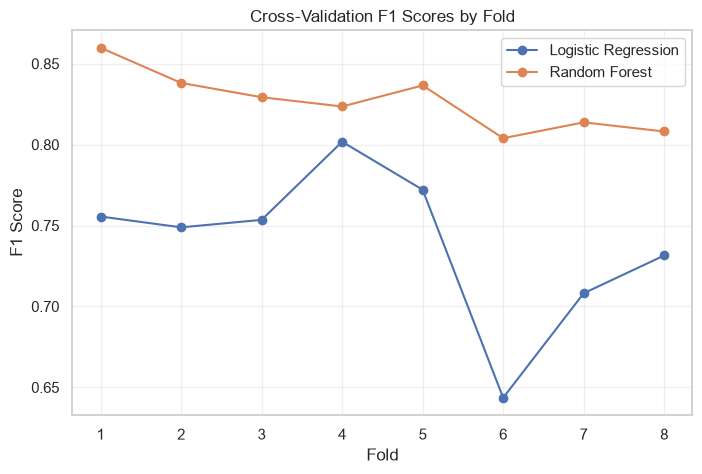

In [24]:
cv_scores_lr = cross_val_score(log_reg, X, y, cv=8, scoring="f1")
cv_scores_rf = cross_val_score(rf, X, y, cv=8, scoring="f1")

cv_compare = pd.DataFrame({
    "fold": np.arange(1, 9),
    "logistic_regression_f1": cv_scores_lr,
    "random_forest_f1": cv_scores_rf,
    "difference_rf_minus_lr": cv_scores_rf - cv_scores_lr
})

display(cv_compare.round(3))

t_stat, p_value = ttest_rel(cv_scores_rf, cv_scores_lr)

print("Mean LR F1:", round(cv_scores_lr.mean(), 3))
print("Mean RF F1:", round(cv_scores_rf.mean(), 3))
print("Mean difference:", round((cv_scores_rf - cv_scores_lr).mean(), 3))
print("Paired t-test p-value:", round(p_value, 5))

plt.figure(figsize=(8, 5))
plt.plot(cv_compare["fold"], cv_compare["logistic_regression_f1"], marker="o", label="Logistic Regression")
plt.plot(cv_compare["fold"], cv_compare["random_forest_f1"], marker="o", label="Random Forest")
plt.title("Cross-Validation F1 Scores by Fold")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 33. Interpreting statistical results in ML

When comparing models, do not only ask:

```text
Which score is higher?
```

Ask:

1. Is the difference practically important?
2. Is the difference statistically reliable?
3. Is the test set large enough?
4. Are scores stable across folds?
5. Does the better model also make sense for deployment?
6. What is the cost of false positives and false negatives?

A statistically significant improvement may be too small to matter.

A practically large improvement may fail to be significant if sample size is too small.

# 34. Mini project — A/B Test and ML Experiment Report

Your task is to create a full statistical experiment report.

## Part A — A/B test

Scenario:

You tested two website versions.

Required:

1. Simulate or load conversion data for A and B  
2. Calculate conversion rates  
3. Calculate confidence interval for each group  
4. Calculate difference in conversion rates  
5. Run two-proportion z-test  
6. Interpret p-value  
7. Write business recommendation  

## Part B — ML model comparison

Required:

1. Train two ML models  
2. Calculate test accuracy and F1  
3. Calculate confidence interval for accuracy  
4. Run cross-validation  
5. Compare fold scores  
6. Use paired t-test on fold scores  
7. Write final recommendation  

## Required insights

Write at least 8 insights.

Examples:

- Group B has higher observed conversion than A.
- The confidence interval shows uncertainty around the estimate.
- p-value below 0.05 suggests the difference is unlikely under H0.
- Model score difference should be judged statistically and practically.
- Cross-validation stability matters more than one lucky test split.

In [ ]:
# Mini project starter

def two_proportion_z_test(success_A, total_A, success_B, total_B):
    p_A = success_A / total_A
    p_B = success_B / total_B

    pooled = (success_A + success_B) / (total_A + total_B)
    se = np.sqrt(pooled * (1 - pooled) * (1/total_A + 1/total_B))

    z = (p_B - p_A) / se
    p = 2 * (1 - norm.cdf(abs(z)))

    return {
        "p_A": p_A,
        "p_B": p_B,
        "difference": p_B - p_A,
        "z_statistic": z,
        "p_value": p
    }

ab_result = two_proportion_z_test(x_A, n_A, x_B, n_B)

display(pd.DataFrame([ab_result]).round(5))

# 35. Common mistakes in hypothesis testing

Avoid these mistakes:

## Mistake 1: Saying p-value is probability H0 is true
Wrong. p-value assumes H0 is true.

## Mistake 2: Ignoring effect size
A tiny difference can be significant with huge sample size.

## Mistake 3: Treating non-significant as proof of no effect
Failing to reject H0 does not prove H0 is true.

## Mistake 4: Running many tests without correction
This increases false positives.

## Mistake 5: Looking only at p-value
Always check confidence intervals and practical impact.

## Mistake 6: Changing hypothesis after seeing data
This leads to biased conclusions.

## Mistake 7: Using wrong test
Use t-test for means, proportion test for rates, chi-square for categorical association.

# 36. Test selection cheat sheet

| Question | Test / Method |
|---|---|
| Is sample mean different from known value? | One-sample t-test |
| Are two independent group means different? | Two-sample t-test |
| Did same subjects improve after treatment? | Paired t-test |
| Are two categorical variables associated? | Chi-square test |
| Are two conversion rates different? | Two-proportion z-test |
| What is uncertainty around a mean? | Confidence interval for mean |
| What is uncertainty around accuracy? | Confidence interval for proportion |
| Is model score stable? | Cross-validation |
| Are paired fold scores different? | Paired t-test |
| Formula is hard? | Bootstrap confidence interval |

# 37. Practice questions

Answer these in your own words.

1. Why are sample results uncertain?
2. What is sampling variation?
3. What is a sampling distribution?
4. What is standard error?
5. Difference between standard deviation and standard error?
6. What does Central Limit Theorem say?
7. What is a confidence interval?
8. How should we interpret a 95% confidence interval?
9. What is a bootstrap confidence interval?
10. What is the null hypothesis?
11. What is the alternative hypothesis?
12. What is a p-value?
13. What does alpha = 0.05 mean?
14. What is Type I error?
15. What is Type II error?
16. What is statistical power?
17. When do we use a one-sample t-test?
18. When do we use a two-sample t-test?
19. When do we use a paired t-test?
20. When do we use chi-square test?
21. What is an A/B test?
22. Why is effect size important?
23. Why does multiple testing cause problems?
24. How can confidence intervals help evaluate ML metrics?
25. Why should model comparison use cross-validation?

# 38. What we learned

In this notebook, we learned:

- Sample results vary because samples are random
- Sampling distribution shows how a statistic varies across samples
- Standard error measures uncertainty of an estimate
- Central Limit Theorem explains why sample means become normal
- Confidence intervals give plausible ranges for population values
- Proportions like conversion rate and accuracy can have confidence intervals
- Bootstrap can estimate confidence intervals through resampling
- Hypothesis testing compares observed results to a null assumption
- p-value measures how surprising the result is under H0
- Type I and Type II errors are testing mistakes
- t-tests compare means
- chi-square test checks categorical association
- A/B testing compares business experiment versions
- Multiple testing can create false discoveries
- ML model scores should be interpreted with uncertainty
- Cross-validation helps compare model stability

---

# Next Notebook

Notebook 5 will cover:

# Statistical Thinking for Model Evaluation

We will learn:

- bias and variance
- overfitting and underfitting
- train/validation/test split statistically
- cross-validation deeper
- metric uncertainty
- model comparison
- calibration
- residual analysis
- error analysis
- data drift
- statistical monitoring of deployed models